# Phase 5 — SHAP Explainability + Retention Levers

Open up the model. Explain each flag. Pair it with a lever the retention team can pull.

**Sections**
- A. Setup — retrain XGBoost (uncalibrated) for SHAP
- B. Compute SHAP values
- C. Global feature importance
- D. Summary plot (beeswarm)
- E. Feature dependence — top 3 drivers
- F. Local explanations — three example users
- G. Feature → intervention mapping
- H. Handoff to Phase 6

> **Why not use `xgb.feature_importances_`?**
> Built-in importance counts training-time split gain — biased toward high-cardinality features, no direction. SHAP is prediction-time, direction-aware, and gives per-user explanations. Right tool for a decision-support system.

> **Why the uncalibrated model, not the calibrated one?**
> Calibration is a monotonic post-hoc transform. It changes probability scale, not ranking or attribution. Cleaner to run TreeExplainer on the raw XGBoost.

In [11]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split

from src.data.loader import load_subscribers
from src.features.transforms import build_features
from src.models.train import prepare_features, train_xgboost
from src.models.explain import (
    compute_shap_values, global_importance, local_explanation,
    map_to_intervention, FEATURE_INTERVENTION_MAP,
)

FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## A. Setup

Same three-way split as Phase 4, same seed. Retraining is deterministic and fast (~10s).

In [12]:
raw = load_subscribers('../data/subscribers.csv')
df = build_features(raw)
X, y = prepare_features(df)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,
)
X_train, X_calib, y_train, y_calib = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42,
)

xgb = train_xgboost(X_train, y_train)
print(f'Retrained XGBoost on train (n={len(X_train):,}) for SHAP analysis')

Retrained XGBoost on train (n=30,000) for SHAP analysis


## B. Compute SHAP values

TreeExplainer runs exact TreeSHAP — polynomial time, no approximation. We sample 2000 users just to keep the beeswarm readable.

Values are in **log-odds space**. Rough conversion: `Δp ≈ Δlog_odds × p × (1-p)`.

In [13]:
SAMPLE_SIZE = 2000
shap_values = compute_shap_values(xgb, X_test, sample_size=SAMPLE_SIZE)
X_shap = X_test.sample(n=SAMPLE_SIZE, random_state=42)
y_shap = y_test.loc[X_shap.index]

print(f'Computed SHAP for {SAMPLE_SIZE} test users')
print(f'Base value (expected log-odds): {shap_values.base_values[0]:.4f}')
print(f'Base value (as probability):    {1/(1+np.exp(-shap_values.base_values[0])):.4f}')

# Sanity check: sum(SHAP) + base_value == raw model output
sample_pred = xgb.predict(X_shap.iloc[[0]], output_margin=True)[0]
sample_check = shap_values.values[0].sum() + shap_values.base_values[0]
print(f'\nSanity check (should match):')
print(f'  raw model margin: {sample_pred:.4f}')
print(f'  sum(shap)+base:   {sample_check:.4f}')

Computed SHAP for 2000 test users
Base value (expected log-odds): -2.9097
Base value (as probability):    0.0517

Sanity check (should match):
  raw model margin: -3.8993
  sum(shap)+base:   -3.8993


> **Sanity check first.**
> SHAP's additive property: `raw_prediction = base + sum(shap_values)`. If these don't match, something's wrong with the setup (wrong model type, wrong feature order). Always verify before trusting any downstream chart.

## C. Global feature importance

Rank by mean |SHAP| — how much each feature typically moves a prediction. Direction ignored here; we cover that next.

In [14]:
importance = global_importance(shap_values, list(X_shap.columns), top_n=15)
importance

,feature,mean_abs_shap,mean_signed_shap
0,watch_hours_last_7d,0.275681,-0.081516
1,billing_cycle_annual,0.247276,-0.055661
2,days_since_last_login,0.228046,-0.060274
3,payment_health_score,0.188039,-0.029581
4,tenure_months,0.161667,-0.034980
5,logins_last_30d,0.153866,-0.035615
6,watch_trend_7d_to_30d,0.150383,-0.047375
7,multi_profile,0.098942,-0.010412
8,watch_trend_30d_to_90d,0.097465,-0.025165
9,watch_hours_last_90d,0.089099,-0.041478


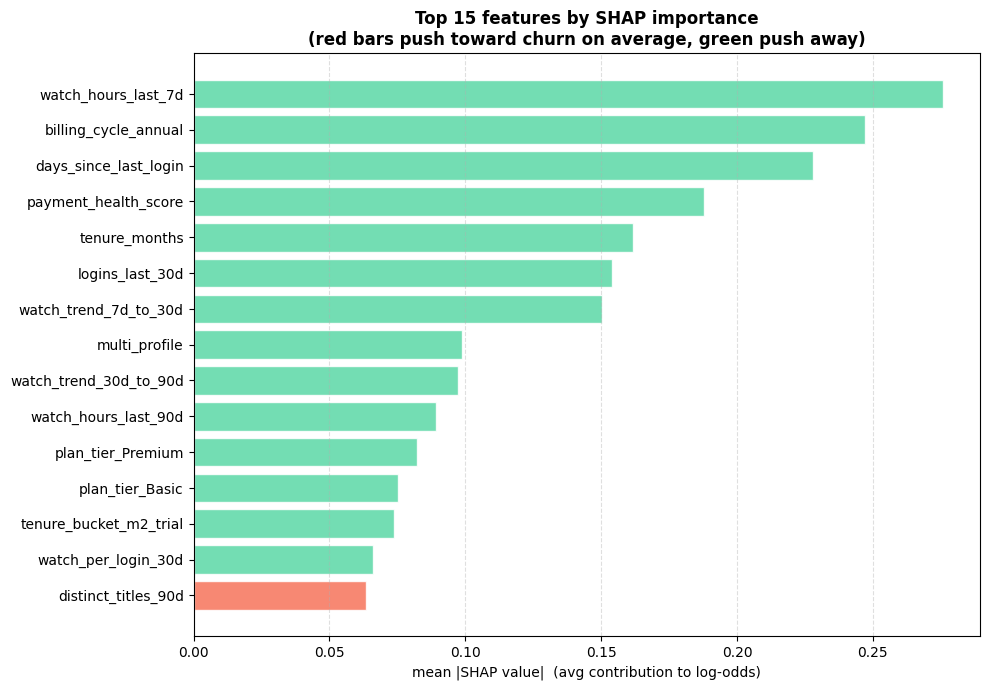

In [15]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#F6735B' if v > 0 else '#5AD8A6'
          for v in importance['mean_signed_shap']]
ax.barh(importance['feature'][::-1], importance['mean_abs_shap'][::-1],
        color=colors[::-1], alpha=0.85, edgecolor='white')
ax.set_xlabel('mean |SHAP value|  (avg contribution to log-odds)')
ax.set_title('Top 15 features by SHAP importance\n'
             '(red bars push toward churn on average, green push away)',
             fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_shap_global_importance.png', dpi=140, bbox_inches='tight')
plt.show()

> **Reading the bars.**
> Red = feature averages toward churn. Green = averages toward retain. Features with big |SHAP| but ≈0 mean signed value affect different users in different directions — the beeswarm below shows that split.

## D. Summary plot (beeswarm)

Most useful SHAP chart. Each row = a feature. Each dot = one user. X = SHAP value (right pushes toward churn). Color = feature value (red high, blue low).

**Reading it**
- Red-right / blue-left: high values increase churn
- Red-left / blue-right: high values decrease churn
- Colors mixed: effect depends on context (interactions)

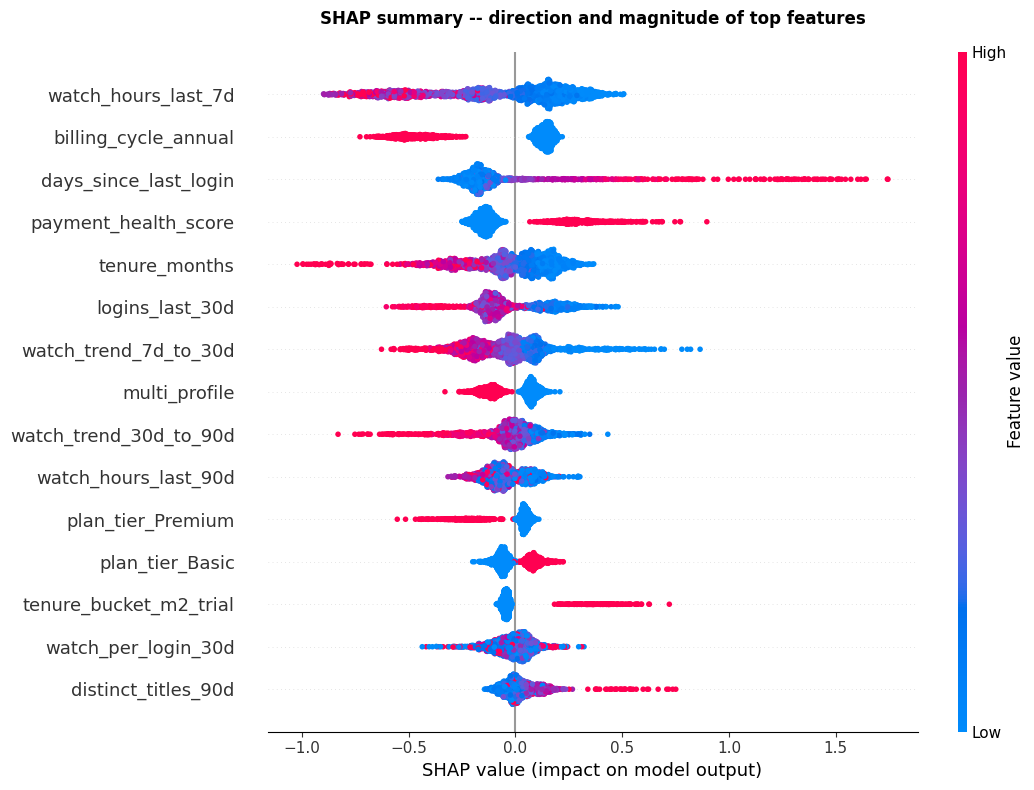

In [16]:
plt.figure(figsize=(11, 8))
shap.summary_plot(shap_values, X_shap, max_display=15, show=False, plot_size=None)
plt.title('SHAP summary -- direction and magnitude of top features',
          fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_shap_beeswarm.png', dpi=140, bbox_inches='tight')
plt.show()

> **Mixed colors = interactions matter.**
> If top features all show clean color separation, a linear baseline would do about as well. Which matches Phase 4 — LR came in ~1 PR-AUC point below XGBoost.

## E. Feature dependence — top 3 drivers

Scatter feature value (x) vs SHAP (y) for one feature at a time. Reveals the *shape* of the effect — linear, threshold, saturating, or curved.

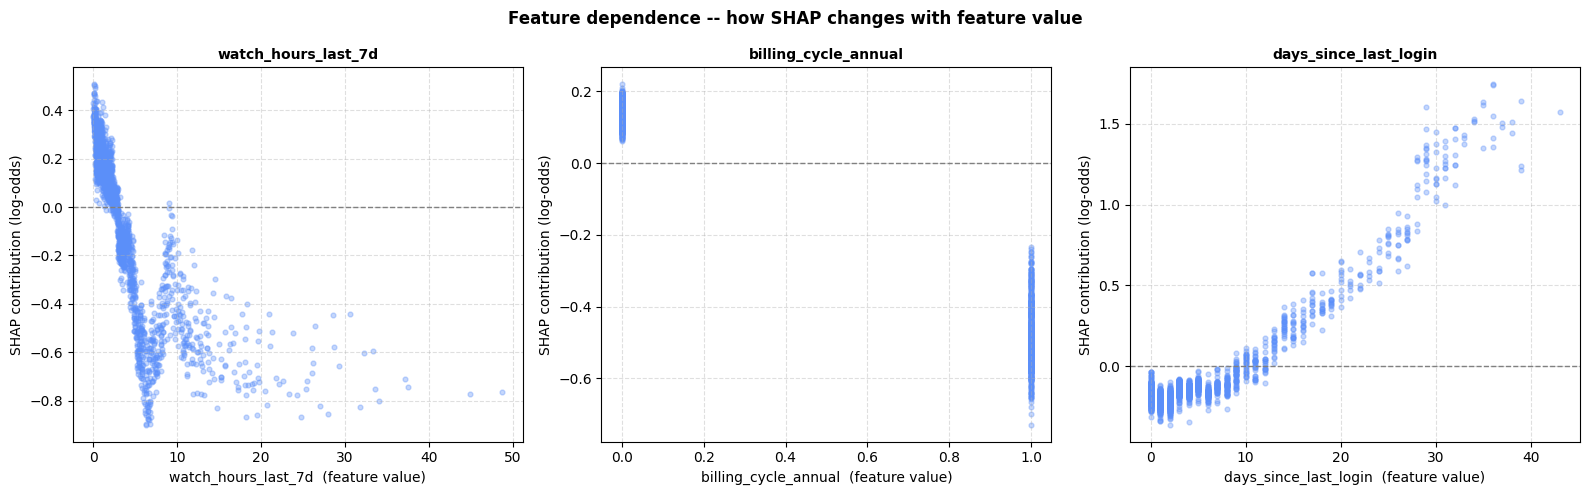

Top 3 drivers: ['watch_hours_last_7d', 'billing_cycle_annual', 'days_since_last_login']


In [38]:
top_3 = importance['feature'].head(3).tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, top_3):
    idx = list(X_shap.columns).index(feat)
    x = X_shap.iloc[:, idx].values
    s = shap_values.values[:, idx]
    ax.scatter(x, s, alpha=0.35, s=12, color='#5B8FF9')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel(f'{feat}  (feature value)')
    ax.set_ylabel('SHAP contribution (log-odds)')
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Feature dependence -- how SHAP changes with feature value',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_shap_dependence.png', dpi=140, bbox_inches='tight')
plt.show()

print(f'Top 3 drivers: {top_3}')

> **What dependence adds over the beeswarm.**
> Beeswarm shows *how much* each feature matters overall. Dependence shows *at what value* the effect kicks in. Threshold effects (flat then a jump) give the team an interpretable rule instead of a black-box score — e.g. "flag if `days_since_last_login` > 14" beats "flag if risk score > 0.32".

## F. Local explanations — three example users

Pick three users at different risk levels, print the top contributing features for each. This is what a CS agent would see on their dashboard.

In [18]:
pred_proba = xgb.predict_proba(X_shap)[:, 1]

example_indices = [
    ('HIGH RISK', int(np.argmax(pred_proba))),
    ('MARGINAL',  int(np.argmin(np.abs(pred_proba - 0.15)))),
    ('LOW RISK',  int(np.argmin(pred_proba))),
]

for label, idx in example_indices:
    p = pred_proba[idx]
    actual = int(y_shap.iloc[idx])
    print(f'\n{"="*70}')
    print(f'[{label}]  P(churn)={p:.3f}  actual={actual}')
    print(f'{"="*70}')
    local = local_explanation(shap_values, X_shap, list(X_shap.columns),
                              idx=idx, top_n=6)
    print(local.to_string(index=False))

    top_risk = local[local['direction'] == 'RISK+'].head(1)
    if not top_risk.empty:
        feat = top_risk['feature'].iloc[0]
        lever = map_to_intervention(feat)
        print(f'\nTop intervention lever: {lever["lever"]}  (cost=${lever["cost"]:.0f})')
        print(f'Reason: {lever["note"]}')


[HIGH RISK]  P(churn)=0.569  actual=0
              feature  feature_value  shap_value direction
days_since_last_login      32.000000    1.307050     RISK+
watch_trend_7d_to_30d       0.568272    0.591709     RISK+
      logins_last_30d       2.000000    0.326750     RISK+
 payment_health_score       1.000000    0.274103     RISK+
 watch_hours_last_90d      80.300000   -0.163959     RISK-
  watch_per_login_30d       9.050000   -0.156636     RISK-

Top intervention lever: Re-engagement email sequence  (cost=$1)
Reason: Inactive users need a reason to come back

[MARGINAL]  P(churn)=0.150  actual=0
               feature  feature_value  shap_value direction
 days_since_last_login      30.000000    1.048047     RISK+
tenure_bucket_m2_trial       1.000000    0.589098     RISK+
   watch_hours_last_7d       6.600000   -0.544307     RISK-
 watch_trend_7d_to_30d       1.188475   -0.359433     RISK-
       logins_last_30d       3.000000    0.231221     RISK+
    distinct_titles_7d       7.0000

> **Every flag comes with a reason.**
> "User X is at 65% risk because of A, B, C → recommended intervention: D (\$Y, expected uplift E)." Phase 6 turns that into an ROI decision. Without SHAP you'd only know the risk score — not why, and not what to do.

## G. Feature → intervention mapping

The bridge from model output to team action. Each top feature paired with a concrete lever + cost. Curated with the PM so it reflects what the retention team can actually run.

In [19]:
lever_rows = []
for feat, spec in FEATURE_INTERVENTION_MAP.items():
    lever_rows.append({
        'feature': feat,
        'lever': spec['lever'],
        'cost': f'${spec["cost"]:.0f}',
        'note': spec['note'],
    })
lever_df = pd.DataFrame(lever_rows)
lever_df

,feature,lever,cost,note
0,watch_trend_7d_to_30d,Personalized content push,$1,Declining engagement -> curated playlist push ...
1,watch_trend_30d_to_90d,Personalized content push,$1,Slow-burn disengagement -> re-engagement email...
2,days_since_last_login,Re-engagement email sequence,$1,Inactive users need a reason to come back
3,logins_last_30d,Re-engagement email sequence,$1,Low login frequency -> weekly recap emails
4,support_tickets_7d,White-glove support callback,$5,Recent ticket escalation -> proactive support ...
5,tickets_recency_ratio,White-glove support callback,$5,Sudden burst of tickets = frustration; catch b...
6,payment_failures_30d,Payment method update prompt + $5 credit,$5,Failed payments often not a churn decision -- ...
7,payment_failures_recency_ratio,Payment method update prompt + $5 credit,$5,Recent failures spike -> emergency retry + car...
8,payment_health_score,Payment method update prompt + $5 credit,$5,Composite payment risk score
9,days_until_promo_expires,Extend promo or offer tier upgrade,$5,Users on the cusp of losing discounts -- preve...


> **Actionable vs diagnostic.**
> Actionable: engagement decline, payment failures, promo expiry, plan changes, m2-casual cohort — team has a lever.
> Diagnostic: tenure, auto_renew, plan_tier — flags the user but not something we can "fix". Model uses these for scoring. Decision rule uses only actionable ones for lever choice.

## H. Handoff to Phase 6

**What Phase 6 gets from here:**

1. Per-user P(churn) from the calibrated model
2. Per-user top SHAP driver
3. Intervention costs + uplifts from the lever table
4. LTV by tier from the scenario brief

**Phase 6 decision rule:**

```
best_lever(user) = argmax over levers of
    P(churn | user) × uplift(lever) × LTV(tier) − cost(lever)
```

Each user gets one answer: send this lever, no intervention worth it, or escalate.

In [20]:
top_5 = importance.head(5)['feature'].tolist()
print('Top 5 SHAP drivers -- Phase 6 will build the decision rule around these:')
for feat in top_5:
    lever = map_to_intervention(feat)
    actionable = '[ACTIONABLE]' if lever['cost'] > 0 else '[diagnostic]'
    print(f'  {actionable} {feat:<35}  lever: {lever["lever"]}')

n_actionable = sum(1 for f in importance['feature']
                   if map_to_intervention(f)['cost'] > 0)
print(f'\nOf top 15 features, {n_actionable} have an actionable intervention lever.')
print('\nReady for Phase 6 (cost-aware decision rule + ROI sweep).')

Top 5 SHAP drivers -- Phase 6 will build the decision rule around these:
  [diagnostic] watch_hours_last_7d                  lever: N/A (diagnostic feature)
  [ACTIONABLE] billing_cycle_annual                 lever: Upgrade-to-annual offer
  [ACTIONABLE] days_since_last_login                lever: Re-engagement email sequence
  [ACTIONABLE] payment_health_score                 lever: Payment method update prompt + $5 credit
  [diagnostic] tenure_months                        lever: N/A -- structural signal

Of top 15 features, 6 have an actionable intervention lever.

Ready for Phase 6 (cost-aware decision rule + ROI sweep).
